In [1]:
import sys
import os
os.environ["HADOOP_USER_NAME"] = "vudua"
import socket

# Tẩy sạch các biến tham chiếu JVM cũ trong Python để tránh lỗi ConnectionRefusedError
try:
    from pyspark import SparkContext
    from pyspark.sql import SparkSession
    SparkContext._jvm = None
    SparkContext._gateway = None
    SparkSession._instantiatedSession = None
except Exception as e:
    pass

# Thiết lập đường dẫn Python cho PySpark trên Windows để tránh lỗi 'Cannot run program python3'
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# Dừng Spark Session cũ an toàn nếu đang hoạt động (không kích hoạt khởi động lại JVM)
try:
    from pyspark.sql import SparkSession
    active_session = SparkSession.getActiveSession()
    if active_session is not None:
        print("Đang dừng Spark Session cũ...")
        active_session.stop()
except Exception as e:
    pass

# Thêm project root vào sys.path để có thể import schema và config từ src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Tự động phát hiện IP nội bộ của máy này kết nối với cụm mạng Radmin VPN
def get_local_ip():
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s.connect(("26.97.56.101", 80))
        ip = s.getsockname()[0]
        s.close()
        return ip
    except Exception:
        return "127.0.0.1"

# THIẾT LẬP CHẾ ĐỘ CHẠY TRÊN CỤM (CLUSTER MODE)
os.environ["RUN_MODE"] = "cluster"
os.environ["DRIVER_IP"] = get_local_ip()

from src.config.cluster_config import MODE, SPARK_MASTER
from src.config.spark_session import get_spark
from src.config.hdfs_config import SUPERSTORE_DATASET
from src.config.schema import SUPERSTORE_SCHEMA

# Khởi tạo Spark Session chạy trên Cluster kết nối Spark Master
print(f"Khởi tạo Spark Session ở chế độ: {MODE.upper()}")
print(f"Spark Master URI: {SPARK_MASTER}")
print(f"Driver Host IP (Radmin VPN): {os.environ['DRIVER_IP']}")

spark = get_spark("Nhom10_ML_Cluster")

# Xác định đường dẫn nạp dữ liệu và ghi dữ liệu đầu ra (HDFS khi chạy cluster, Cục bộ khi chạy local)
if MODE == "cluster":
    dataset_path = SUPERSTORE_DATASET
    temp_parquet_path = "hdfs://master:9000/bigdata/ml2/temp_ml2_selected.parquet"
    customer_profile_path = "hdfs://master:9000/bigdata/ml2/customer_profile.parquet"
    model_save_path = "hdfs://master:9000/bigdata/ml2/models/best_rf_pipeline_model"
    print(f"Nạp dữ liệu từ HDFS: {dataset_path}")
    print(f"Đường dẫn lưu tạm HDFS: {temp_parquet_path}")
    print(f"Đường dẫn lưu snapshot HDFS: {customer_profile_path}")
    print(f"Đường dẫn lưu model HDFS: {model_save_path}")
else:
    dataset_path = r"D:\\LESSONS\\BigData\\data\\G10_dataset.csv"
    temp_parquet_path = "../streaming/temp_ml2_selected.parquet"
    customer_profile_path = "../streaming/customer_profile.parquet"
    model_save_path = "../streaming/models/best_rf_pipeline_model"
    print(f"Nạp dữ liệu từ Local: {dataset_path}")
    print(f"Đường dẫn lưu tạm Local: {temp_parquet_path}")
    print(f"Đường dẫn lưu snapshot Local: {customer_profile_path}")
    print(f"Đường dẫn lưu model Local: {model_save_path}")

# Đọc dữ liệu từ file sử dụng schema có sẵn
df = (
    spark.read
    .option("header", "true")
    .option("dateFormat", "yyyy-MM-dd")
    .schema(SUPERSTORE_SCHEMA)
    .csv(dataset_path)
)

# Đăng ký Temp View để có thể viết truy vấn SQL nếu cần
df.createOrReplaceTempView("superstore")

print("Đã khởi tạo Spark Cluster và nạp dữ liệu thành công!")
print(f"Tổng số dòng dữ liệu: {df.count()}")

# Hiển thị 5 dòng dữ liệu dưới dạng bảng Pandas đẹp
display(df.limit(5).toPandas())


Khởi tạo Spark Session ở chế độ: CLUSTER
Spark Master URI: spark://master:7077
Driver Host IP (Radmin VPN): 26.105.196.249
Nạp dữ liệu từ HDFS: hdfs://master:9000/bigdata/superstore/input/G10_dataset.csv
Đường dẫn lưu tạm HDFS: hdfs://master:9000/bigdata/ml2/temp_ml2_selected.parquet
Đường dẫn lưu snapshot HDFS: hdfs://master:9000/bigdata/ml2/customer_profile.parquet
Đường dẫn lưu model HDFS: hdfs://master:9000/bigdata/ml2/models/best_rf_pipeline_model
Đã khởi tạo Spark Cluster và nạp dữ liệu thành công!
Tổng số dòng dữ liệu: 500000


,Category,City,Country,Customer_ID,Customer_Name,Discount,Market,Order_Date,Order_ID,Order_Priority,...,Region,Sales,Segment,Ship_Date,Ship_Mode,Shipping_Cost,State,Sub_Category,Year,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07,CA-2011-130813,High,...,West,19.0,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21,CA-2011-148614,Medium,...,West,19.0,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,West,21.0,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,...,West,111.0,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29,CA-2011-146969,High,...,West,6.0,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,40


SCHEMA DỮ LIỆU
root
 |-- Category: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Market: string (nullable = true)
 |-- Order_Date: date (nullable = true)
 |-- Order_ID: string (nullable = true)
 |-- Order_Priority: string (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Ship_Date: date (nullable = true)
 |-- Ship_Mode: string (nullable = true)
 |-- Shipping_Cost: double (nullable = true)
 |-- State: string (nullable = true)
 |-- Sub_Category: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- weeknum: integer (nullable = true)

BẢNG THỐNG

,summary,Profit,Sales,Discount,Shipping_Cost
0,count,497116,497326,500000,497116
1,mean,20.849655862575265,273.62693430506374,0.1705213960000164,30.12954791919793
2,stddev,169.35993821921184,553.8631816503082,0.13001240688743163,67.87982674258897
3,min,-6599.978,0.36,0.0,0.0
4,25%,-6.02,33.0,0.07,2.87
5,50%,5.14,91.67,0.15,8.69
6,75%,28.09,272.93,0.25,27.29
7,max,12756.9,31357.32,0.85,1784.71


BẢNG KIỂM TRA SỐ LƯỢNG GIÁ TRỊ NULL


,Tên cột,Số lượng giá trị Null
0,Category,0
1,City,0
2,Country,0
3,Customer_ID,0
4,Customer_Name,0
5,Discount,0
6,Market,0
7,Order_Date,0
8,Order_ID,0
9,Order_Priority,0


TÍNH TOÁN VÀ VẼ HEATMAP BIÊN LỢI NHUẬN THEO MARKET & CATEGORY


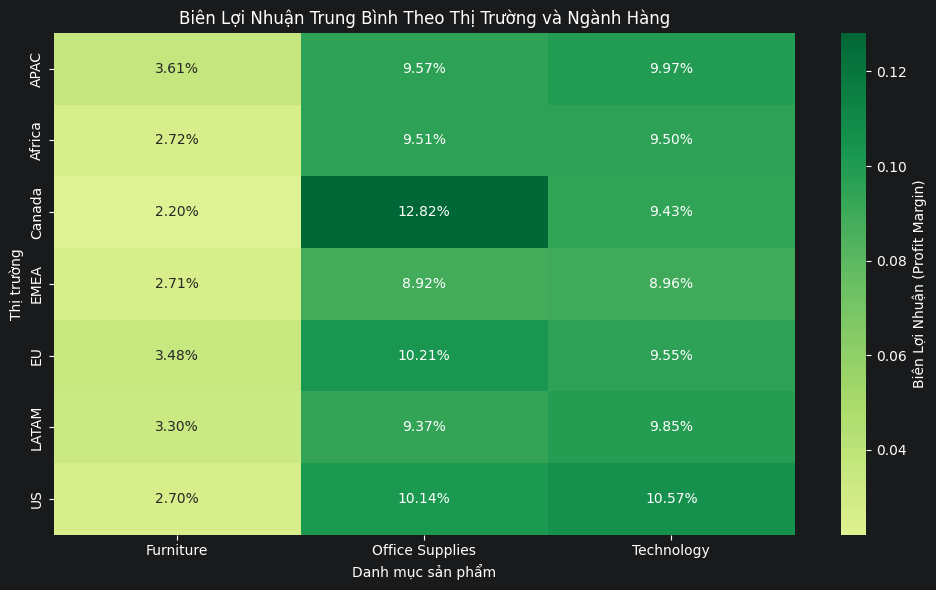

Số đơn hàng bị Lỗ (Profit < 0): 175154 dòng
Số đơn hàng Hòa vốn (Profit = 0): 788 dòng
Số đơn hàng có Lãi (Profit > 0): 321174 dòng


In [2]:
# Giai đoạn 1: Data Understanding
from pyspark.sql.functions import col, sum as spark_sum
import pandas as pd

print("SCHEMA DỮ LIỆU")
df.printSchema()

print("BẢNG THỐNG KÊ MÔ TẢ")
# Chuyển đổi kết quả summary sang Pandas DataFrame để hiển thị đẹp trong Jupyter
display(df.select("Profit", "Sales", "Discount", "Shipping_Cost").summary().toPandas())

print("BẢNG KIỂM TRA SỐ LƯỢNG GIÁ TRỊ NULL")
null_counts = df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).toPandas()
# Xoay dọc bảng thống kê Null vì có tới 24 cột nếu để ngang sẽ khó nhìn
null_counts_vertical = null_counts.T.reset_index()
null_counts_vertical.columns = ["Tên cột", "Số lượng giá trị Null"]
display(null_counts_vertical)

print("TÍNH TOÁN VÀ VẼ HEATMAP BIÊN LỢI NHUẬN THEO MARKET & CATEGORY")
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán tổng Profit và tổng Sales gom nhóm theo Market và Category để tính Profit Margin
df_margin = df.filter(col("Profit").isNotNull() & col("Sales").isNotNull() & (col("Sales") > 0)) \
              .groupBy("Market", "Category") \
              .agg(spark_sum("Profit").alias("total_profit"), spark_sum("Sales").alias("total_sales")) \
              .withColumn("profit_margin", col("total_profit") / col("total_sales"))

pdf_margin = df_margin.select("Market", "Category", "profit_margin").toPandas()
pivot_margin = pdf_margin.pivot(index="Market", columns="Category", values="profit_margin")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_margin, annot=True, fmt=".2%", cmap="RdYlGn", center=0, cbar_kws={'label': 'Biên Lợi Nhuận (Profit Margin)'})
plt.title("Biên Lợi Nhuận Trung Bình Theo Thị Trường và Ngành Hàng")
plt.xlabel("Danh mục sản phẩm")
plt.ylabel("Thị trường")
plt.tight_layout()
plt.show()
negative_profit_count = df.filter(col("Profit") < 0).count()
zero_profit_count = df.filter(col("Profit") == 0).count()
positive_profit_count = df.filter(col("Profit") > 0).count()
print(f"Số đơn hàng bị Lỗ (Profit < 0): {negative_profit_count} dòng")
print(f"Số đơn hàng Hòa vốn (Profit = 0): {zero_profit_count} dòng")
print(f"Số đơn hàng có Lãi (Profit > 0): {positive_profit_count} dòng")


In [3]:
# Giai đoạn 2: Feature Engineering & Data Cleaning (Xử lý Outliers)
from pyspark.sql.functions import col, when, datediff, log, exp, concat_ws, sum as spark_sum, coalesce, lit
from pyspark.sql.window import Window

# 1. Làm sạch và thống kê dữ liệu nhiễu vật lý
total_original = df.count()
print(f"Số dòng ban đầu trong tập dữ liệu: {total_original} dòng")

# Lọc ra các dòng bị loại bỏ (Quantity <= 0 hoặc Sales <= 0 hoặc Null ở các cột này)
df_removed_noise = df.filter(
    (col("Quantity") <= 0) | (col("Sales") <= 0) | 
    col("Quantity").isNull() | col("Sales").isNull()
)
removed_noise_count = df_removed_noise.count()
print(f"Số dòng bị lọc bỏ do nhiễu vật lý hoặc Null (Quantity <= 0, Sales <= 0): {removed_noise_count} dòng")

if removed_noise_count > 0:
    print("\nMẪU 5 DÒNG DỮ LIỆU NHIỄU BỊ LỌC BỎ")
    display(df_removed_noise.limit(5).toPandas())

# Tiến hành giữ lại dữ liệu sạch
df_clean = df.filter((col("Quantity") > 0) & (col("Sales") > 0))
print(f"\nSố dòng sạch giữ lại sau khi lọc: {df_clean.count()} dòng (Đã giảm {removed_noise_count} dòng nhiễu)")

# 2. Tính phân vị 1% và 99% để kẹp biên (Winsorization) cho Sales và Shipping_Cost
sales_quantiles = df_clean.approxQuantile("Sales", [0.01, 0.99], 0.01)
ship_quantiles = df_clean.approxQuantile("Shipping_Cost", [0.01, 0.99], 0.01)

sales_p1, sales_p99 = sales_quantiles[0], sales_quantiles[1]
ship_p1, ship_p99 = ship_quantiles[0], ship_quantiles[1]

print(f"\nSales Winsorization thresholds: P1 = {sales_p1}, P99 = {sales_p99}")
print(f"Shipping_Cost Winsorization thresholds: P1 = {ship_p1}, P99 = {ship_p99}")

# Tiến hành kẹp biên (Capping outliers)
df_clean = df_clean.withColumn("Sales_capped", 
    when(col("Sales") < sales_p1, sales_p1)
    .when(col("Sales") > sales_p99, sales_p99)
    .otherwise(col("Sales"))
).withColumn("Shipping_Cost_capped", 
    when(col("Shipping_Cost") < ship_p1, ship_p1)
    .when(col("Shipping_Cost") > ship_p99, ship_p99)
    .otherwise(col("Shipping_Cost"))
)

# 3. Tạo đặc trưng tích lũy lịch sử khách hàng (Customer Historical Profiles) dùng Spark Window
# Lưu ý: rowsBetween(Window.unboundedPreceding, -1) loại trừ dòng hiện tại để ngăn chặn rò rỉ thông tin mục tiêu (Target Leakage)
customer_window = Window.partitionBy("Customer_ID").orderBy("Order_Date").rowsBetween(Window.unboundedPreceding, -1)

df_feat = df_clean.withColumn("cust_hist_sales", coalesce(spark_sum("Sales_capped").over(customer_window), lit(0.0))) \
    .withColumn("cust_hist_profit", coalesce(spark_sum("Profit").over(customer_window), lit(0.0)))

df_feat = df_feat.withColumn("cust_hist_margin", 
    when(col("cust_hist_sales") == 0, 0.0)
    .otherwise(col("cust_hist_profit") / col("cust_hist_sales"))
)

# 4. Tạo các đặc trưng mới (Feature Engineering)
df_feat = df_feat.withColumn("discount_amount", col("Sales_capped") * col("Discount")) \
    .withColumn("shipping_ratio", when(col("Sales_capped") == 0, 0.0).otherwise(col("Shipping_Cost_capped") / col("Sales_capped"))) \
    .withColumn("avg_item_value", when(col("Quantity") == 0, 0.0).otherwise(col("Sales_capped") / col("Quantity"))) \
    .withColumn("delivery_days", datediff(col("Ship_Date"), col("Order_Date"))) \
    .withColumn("is_discounted", when(col("Discount") > 0, 1.0).otherwise(0.0)) \
    .withColumn("high_discount", when(col("Discount") >= 0.2, 1.0).otherwise(0.0))

# 5. Phép tương tác đặc trưng phân loại (Market x Category)
df_feat = df_feat.withColumn("Market_Category", concat_ws("_", col("Market"), col("Category")))

# 6. Biến đổi Logarithmic cho biến mục tiêu Profit (dịch chuyển c = 3000.0 để xử lý Profit âm)
c_shift = 3000.0
df_feat = df_feat.withColumn("log_profit", log(col("Profit") + c_shift))

print("\nTạo các đặc trưng nâng cao thành công: cust_hist_sales, cust_hist_profit, cust_hist_margin, Market_Category, log_profit.")

# Hiển thị mẫu các dòng dữ liệu với các đặc trưng mới để đối chiếu kết quả
print("\nMẪU DỮ LIỆU SAU BIẾN ĐỔI")
sample_cols = ["Customer_ID", "Order_Date", "Sales_capped", "Profit", "cust_hist_sales", "cust_hist_profit", "cust_hist_margin", "Market", "Category", "Market_Category", "log_profit"]
display(df_feat.select(*sample_cols).filter(col("cust_hist_sales") > 0).limit(5).toPandas())


Số dòng ban đầu trong tập dữ liệu: 500000 dòng
Số dòng bị lọc bỏ do nhiễu vật lý hoặc Null (Quantity <= 0, Sales <= 0): 2884 dòng

MẪU 5 DÒNG DỮ LIỆU NHIỄU BỊ LỌC BỎ


,Category,City,Country,Customer_ID,Customer_Name,Discount,Market,Order_Date,Order_ID,Order_Priority,...,Region,Sales,Segment,Ship_Date,Ship_Mode,Shipping_Cost,State,Sub_Category,Year,weeknum
0,Office Supplies,Los Angeles,United States,JO-152804,Jas O'Carroll,0.0,US,2013-04-20,US-2013-115819,Medium,...,4,NaN,23,None,2013-04-25,NaN,3.87,California,NaN,2013
1,Office Supplies,Los Angeles,United States,BD-113204,Bill Donatelli,0.0,US,2013-06-17,CA-2013-148593,Medium,...,5,NaN,46,None,2013-06-19,NaN,1.14,California,NaN,2013
2,Office Supplies,Los Angeles,United States,XP-218654,Xylona Preis,0.0,US,2014-10-10,US-2014-115595,Medium,...,5,NaN,35,None,2014-10-12,NaN,7.79,California,NaN,2014
3,Office Supplies,Los Angeles,United States,BP-110954,Bart Pistole,0.0,US,2012-03-23,CA-2012-138219,Medium,...,4,NaN,33,None,2012-03-30,NaN,2.16,California,NaN,2012
4,Office Supplies,Los Angeles,United States,CG-120404,Catherine Glotzbach,0.0,US,2012-06-01,CA-2012-161242,Medium,...,2,NaN,12,None,2012-06-08,NaN,0.82,California,NaN,2012



Số dòng sạch giữ lại sau khi lọc: 497116 dòng (Đã giảm 2884 dòng nhiễu)

Sales Winsorization thresholds: P1 = 0.36, P99 = 31357.32
Shipping_Cost Winsorization thresholds: P1 = 0.0, P99 = 1784.71

Tạo các đặc trưng nâng cao thành công: cust_hist_sales, cust_hist_profit, cust_hist_margin, Market_Category, log_profit.

MẪU DỮ LIỆU SAU BIẾN ĐỔI


,Customer_ID,Order_Date,Sales_capped,Profit,cust_hist_sales,cust_hist_profit,cust_hist_margin,Market,Category,Market_Category,log_profit
0,AA-104804,2013-07-18,22.0,10.0878,27.0,9.8856,0.366133,US,Office Supplies,US_Office Supplies,8.009725
1,AA-104804,2013-07-18,52.0,25.4016,49.0,19.9734,0.407620,US,Office Supplies,US_Office Supplies,8.014799
2,AA-104804,2013-07-18,243.0,4.8588,101.0,45.3750,0.449257,US,Office Supplies,US_Office Supplies,8.007986
3,AA-104804,2013-07-18,265.0,47.7306,344.0,50.2338,0.146028,US,Office Supplies,US_Office Supplies,8.022153
4,AA-104804,2013-08-27,9.0,2.5056,609.0,97.9644,0.160861,US,Office Supplies,US_Office Supplies,8.007202


In [4]:
# Giai đoạn 2 (Bổ sung): Feature Leakage Audit (Kiểm toán rò rỉ mục tiêu)
print("KIỂM TOÁN RÒ RỈ MỤC TIÊU")
print("Kiểm tra hệ số tương quan tuyến tính giữa các đặc trưng tích lũy lịch sử khách hàng và biến mục tiêu Profit gốc:")

features_to_audit = ["cust_hist_sales", "cust_hist_profit", "cust_hist_margin"]
leakage_detected = False

for f_name in features_to_audit:
    corr_val = df_feat.stat.corr(f_name, "Profit")
    print(f" - Hệ số tương quan corr({f_name:17}, Profit) = {corr_val:.4f}")
    if abs(corr_val) > 0.95:
        print(f"   Phát hiện rò rỉ mục tiêu trên '{f_name}'! Hệ số tương quan quá lớn (> 0.95).")
        leakage_detected = True
    else:
        print(f"   Đặc trưng '{f_name}' không rò rỉ mục tiêu (hệ số tương quan {corr_val:.4f} nằm trong ngưỡng an toàn).")

if not leakage_detected:
    print("\nTất cả các đặc trưng lịch sử tích lũy đã VƯỢT QUA kiểm toán rò rỉ mục tiêu.")
else:
    print("\nCần xem lại cách xây dựng đặc trưng để tránh rò rỉ thông tin trước thời điểm xảy ra đơn hàng!")



KIỂM TOÁN RÒ RỈ MỤC TIÊU
Kiểm tra hệ số tương quan tuyến tính giữa các đặc trưng tích lũy lịch sử khách hàng và biến mục tiêu Profit gốc:
 - Hệ số tương quan corr(cust_hist_sales  , Profit) = 0.0456
   Đặc trưng 'cust_hist_sales' không rò rỉ mục tiêu (hệ số tương quan 0.0456 nằm trong ngưỡng an toàn).
 - Hệ số tương quan corr(cust_hist_profit , Profit) = 0.0472
   Đặc trưng 'cust_hist_profit' không rò rỉ mục tiêu (hệ số tương quan 0.0472 nằm trong ngưỡng an toàn).
 - Hệ số tương quan corr(cust_hist_margin , Profit) = 0.0477
   Đặc trưng 'cust_hist_margin' không rò rỉ mục tiêu (hệ số tương quan 0.0477 nằm trong ngưỡng an toàn).

Tất cả các đặc trưng lịch sử tích lũy đã VƯỢT QUA kiểm toán rò rỉ mục tiêu.


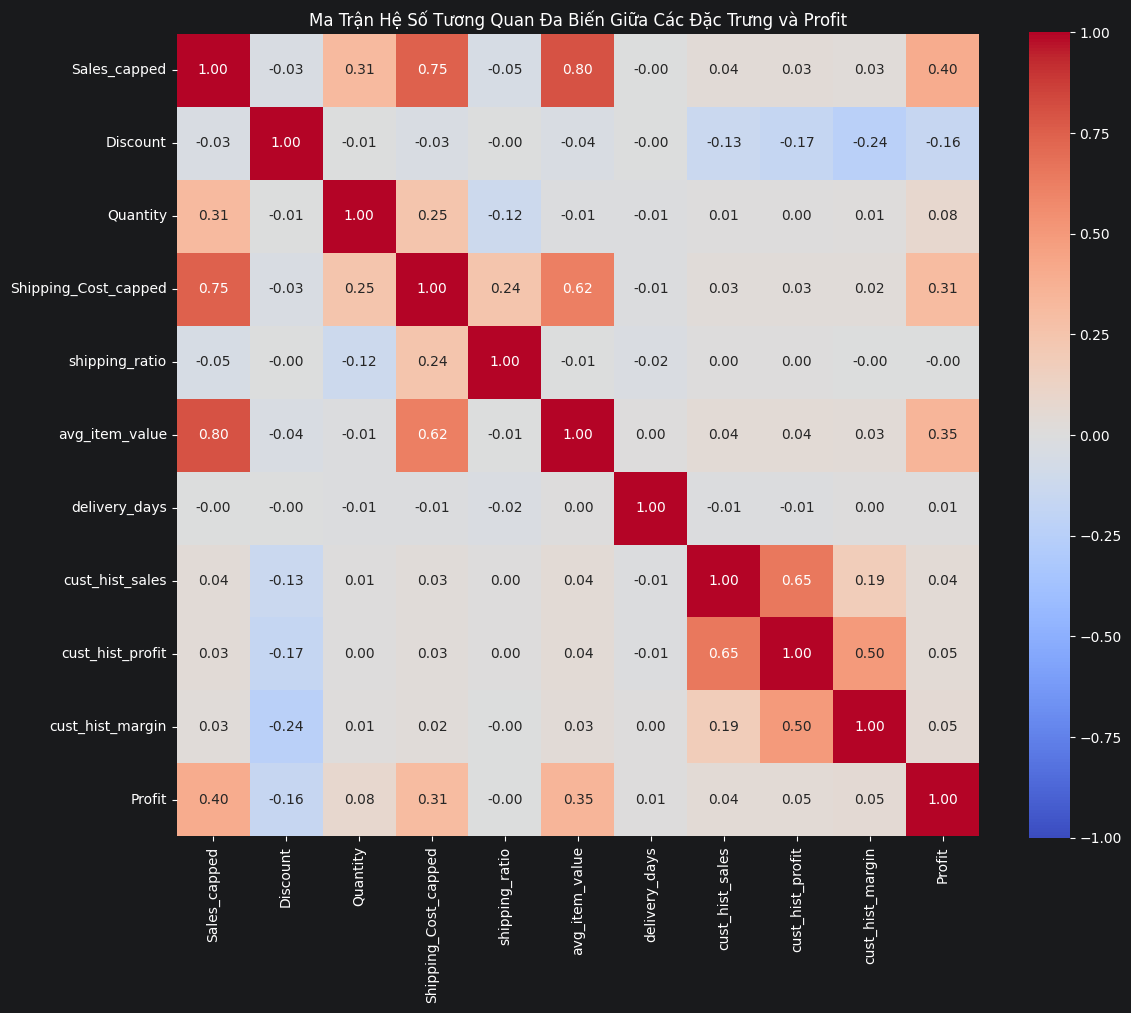

In [5]:
# Giai đoạn 2 (Bổ sung): Correlation Analysis & Heatmap (Kiểm tra tương quan đa biến)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

corr_cols = [
    "Sales_capped", "Discount", "Quantity", "Shipping_Cost_capped",
    "shipping_ratio", "avg_item_value", "delivery_days",
    "cust_hist_sales", "cust_hist_profit", "cust_hist_margin", "Profit"
]

# Trích xuất 10% mẫu dữ liệu sạch chuyển sang Pandas để tính tương quan nhanh gọn
pdf_corr = df_feat.select(*corr_cols).sample(False, 0.1, seed=42).toPandas()
corr_matrix = pdf_corr.corr()

# Vẽ Heatmap tương quan
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True)
plt.title("Ma Trận Hệ Số Tương Quan Đa Biến Giữa Các Đặc Trưng và Profit")
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_correlation_heatmap.png"), dpi=300)
plt.show()



In [6]:
# Giai đoạn 3: Feature Selection
features_numeric = [
    "Sales_capped", "Quantity", "Discount", "Shipping_Cost_capped", "Year", "weeknum",
    "discount_amount", "shipping_ratio", "avg_item_value", "delivery_days",
    "is_discounted", "high_discount", "cust_hist_sales", "cust_hist_profit", "cust_hist_margin"
]

features_categorical = [
    "Category", "Sub_Category", "Segment", "Market", "Region", "Ship_Mode", "Order_Priority", "Market_Category"
]

target_col = "log_profit"

# Giữ lại cột Profit gốc để phục vụ đánh giá quy đổi sai số USD, và Customer_ID/Order_Date để tính cửa sổ
selected_cols = features_numeric + features_categorical + [target_col, "Profit", "Customer_ID", "Order_Date"]
df_selected_raw = df_feat.select(*selected_cols).dropna()

# Ghi dữ liệu ra file Parquet tạm để ngắt lineage hoàn toàn, giúp chạy CrossValidator nhanh hơn (không bị recompute Window)
# Sử dụng temp_parquet_path từ Cell 00
df_selected_raw.write.mode("overwrite").parquet(temp_parquet_path)
df_selected = spark.read.parquet(temp_parquet_path)

# Tạo và lưu bảng snapshot lịch sử khách hàng mới nhất (để phục vụ realtime stream join)
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
latest_customer_window = Window.partitionBy("Customer_ID").orderBy(col("Order_Date").desc())
customer_snapshot = df_feat.withColumn("row_num", row_number().over(latest_customer_window)) \
                           .filter(col("row_num") == 1) \
                           .select("Customer_ID", "cust_hist_sales", "cust_hist_profit", "cust_hist_margin")

customer_snapshot.write.mode("overwrite").parquet(customer_profile_path)
# Phân tích và liệt kê các biến bị loại bỏ
all_columns = df_feat.columns
removed_cols = [c for c in all_columns if c not in selected_cols and c != "Profit"]

print("GIAI ĐOẠN 3: LỰA CHỌN ĐẶC TRƯNG")
print(f"Tổng số cột ban đầu (kèm đặc trưng mới): {len(all_columns)}")
print(f"Số cột được lựa chọn để huấn luyện: {len(selected_cols)}")
print(f"Số cột bị loại bỏ: {len(removed_cols)}")
print(f"\nSố dòng dữ liệu sau khi loại bỏ null và giữ lại các biến đặc trưng chọn lọc: {df_selected.count()}")



GIAI ĐOẠN 3: LỰA CHỌN ĐẶC TRƯNG
Tổng số cột ban đầu (kèm đặc trưng mới): 37
Số cột được lựa chọn để huấn luyện: 27
Số cột bị loại bỏ: 10

Số dòng dữ liệu sau khi loại bỏ null và giữ lại các biến đặc trưng chọn lọc: 497094


In [7]:
# Giai đoạn 4 & 5: Encoding & VectorAssembler
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Interaction

# 1. Mã hóa các cột dạng chữ thành số (StringIndexer)
categorical_indices = [c + "_Index" for c in features_categorical]
string_indexer = StringIndexer(
    inputCols=features_categorical,
    outputCols=categorical_indices,
    handleInvalid="keep"
)
# 2. Mã hóa sang dạng Vector One-Hot (OneHotEncoder)
categorical_ohes = [c + "_OHE" for c in features_categorical]
ohe_encoder = OneHotEncoder(
    inputCols=categorical_indices,
    outputCols=categorical_ohes
)

# 3. Phép tương tác đặc trưng (Interaction) giữa Sub_Category (OHE) và Discount
interaction = Interaction(
    inputCols=["Sub_Category_OHE", "Discount"],
    outputCol="subcat_discount_inter"
)

# 4. Gộp tất cả các cột đặc trưng thành một vector duy nhất
assembler_inputs = features_numeric + categorical_ohes + ["subcat_discount_inter"]
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features"
)


# Chạy thử nghiệm các Transformer trên một phần dữ liệu để hiển thị kết quả mã hóa
from pyspark.ml import Pipeline
temp_prep_pipeline = Pipeline(stages=[string_indexer, ohe_encoder])
temp_prep_model = temp_prep_pipeline.fit(df_selected)
df_transformed_sample = temp_prep_model.transform(df_selected)

print("\n Kết quả sau khi mã hóa")
display(df_transformed_sample.select("Category", "Category_Index", "Category_OHE", "Sub_Category", "Sub_Category_Index", "Sub_Category_OHE").limit(5).toPandas())



 Kết quả sau khi mã hóa


,Category,Category_Index,Category_OHE,Sub_Category,Sub_Category_Index,Sub_Category_OHE
0,Furniture,2.0,"(0.0, 0.0, 1.0)",Bookcases,9.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Office Supplies,0.0,"(1.0, 0.0, 0.0)",Art,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Office Supplies,0.0,"(1.0, 0.0, 0.0)",Storage,1.0,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Office Supplies,0.0,"(1.0, 0.0, 0.0)",Binders,0.0,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Technology,1.0,"(0.0, 1.0, 0.0)",Phones,5.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


In [8]:
# Giai đoạn 6: Train/Test Split
train_data, test_data = df_selected.randomSplit([0.8, 0.2], seed=42)
print(f"Kích thước tập huấn luyện: {train_data.count()} dòng")
print(f"Kích thước tập kiểm thử: {test_data.count()} dòng")


Kích thước tập huấn luyện: 397798 dòng
Kích thước tập kiểm thử: 99296 dòng


In [9]:
# Giai đoạn 7, 8, 9 & 10: Model Definition, Pipelines & Training
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor

# Khởi tạo các mô hình hồi quy (huấn luyện trên biến mục tiêu log_profit)
lr = LinearRegression(featuresCol="features", labelCol="log_profit")
rf = RandomForestRegressor(featuresCol="features", labelCol="log_profit", numTrees=100, maxDepth=8, seed=42)
gbt = GBTRegressor(featuresCol="features", labelCol="log_profit", maxIter=20, maxDepth=5, seed=42)

# Đóng gói các bước tiền xử lý và mô hình thành Pipeline
pipeline_lr = Pipeline(stages=[string_indexer, ohe_encoder, interaction, assembler, lr])
pipeline_rf = Pipeline(stages=[string_indexer, ohe_encoder, interaction, assembler, rf])
pipeline_gbt = Pipeline(stages=[string_indexer, ohe_encoder, interaction, assembler, gbt])

# Huấn luyện các mô hình trên tập Train
print("Đang huấn luyện Baseline Model (Linear Regression)...")
model_lr = pipeline_lr.fit(train_data)

print("Đang huấn luyện Main Model (Random Forest)...")
model_rf = pipeline_rf.fit(train_data)

print("Đang huấn luyện Advanced Model (GBT Regressor)...")
model_gbt = pipeline_gbt.fit(train_data)

print("Hoàn thành!")


Đang huấn luyện Baseline Model (Linear Regression)...
Đang huấn luyện Main Model (Random Forest)...
Đang huấn luyện Advanced Model (GBT Regressor)...
Hoàn thành!


In [10]:
 # Giai đoạn 11: Hyperparameter Tuning cho Random Forest
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

# Cấu hình lưới tìm kiếm tham số cho Random Forest (chạy local tối ưu)
param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 8])
    .build()
)

# Đánh giá thặng dư log_profit trong quá trình tuning
evaluator_rmse_log = RegressionEvaluator(labelCol="log_profit", predictionCol="prediction", metricName="rmse")

# Sử dụng 2-Fold Cross Validation cho môi trường chạy local nhanh gọn
cv = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=param_grid,
    evaluator=evaluator_rmse_log,
    numFolds=2,
    seed=42
)

print("Đang thực hiện Hyperparameter Tuning với CrossValidator ...")
cv_model = cv.fit(train_data)
best_model_rf = cv_model.bestModel

# Lấy ra các tham số tốt nhất
best_rf_model = best_model_rf.stages[-1]
print("Thông tin mô hình Random Forest tối ưu nhất:")
print(best_rf_model)

# Lưu toàn bộ PipelineModel tốt nhất để phục vụ dự đoán Realtime
# Sử dụng model_save_path từ Cell 00
best_model_rf.write().overwrite().save(model_save_path)




Đang thực hiện Hyperparameter Tuning với CrossValidator ...
Thông tin mô hình Random Forest tối ưu nhất:
RandomForestRegressionModel: uid=RandomForestRegressor_015f864aaa38, numTrees=100, numFeatures=104


In [11]:
# Giai đoạn 12: Đánh giá chi tiết (Evaluation) bao gồm chỉ số Custom
from pyspark.sql.functions import col, abs as spark_abs, mean, when, exp
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

c_shift = 3000.0

def evaluate_predictions(predictions, model_name):
    # Quy đổi dự đoán ngược lại thang đo ban đầu (USD) trước khi tính các sai số thực tế
    predictions_usd = predictions.withColumn("prediction_log", col("prediction")) \
                                 .withColumn("prediction", exp(col("prediction_log")) - c_shift)
    
    # Sử dụng RegressionEvaluator cho các chỉ số cơ bản
    evaluator = RegressionEvaluator(labelCol="Profit", predictionCol="prediction")
    
    rmse = evaluator.evaluate(predictions_usd, {evaluator.metricName: "rmse"})
    mae = evaluator.evaluate(predictions_usd, {evaluator.metricName: "mae"})
    r2 = evaluator.evaluate(predictions_usd, {evaluator.metricName: "r2"})
    
    # Lọc bỏ các bản ghi có Profit = 0 để tránh chia cho 0 trong MAPE, PRED và các chỉ số Relative khác
    df_filtered = predictions_usd.filter(col("Profit") != 0)
    
    # 1. Tính MAPE
    mape_val = df_filtered.select(
        mean(spark_abs((col("Profit") - col("prediction")) / col("Profit"))) * 100
    ).collect()[0][0]
    
    # 2. Tính PRED(25%)
    pred25_val = df_filtered.select(
        mean(when(spark_abs((col("Profit") - col("prediction")) / col("Profit")) <= 0.25, 1.0).otherwise(0.0)) * 100
    ).collect()[0][0]
    
    # 3. Tính MBRE
    mbre_expr = spark_abs(col("Profit") - col("prediction")) / when(
        spark_abs(col("Profit")) < spark_abs(col("prediction")), 
        when(spark_abs(col("Profit")) == 0, 1e-5).otherwise(spark_abs(col("Profit")))
    ).otherwise(
        when(spark_abs(col("prediction")) == 0, 1e-5).otherwise(spark_abs(col("prediction")))
    )
    mbre_val = predictions_usd.select(mean(mbre_expr)).collect()[0][0]
    
    # 4. Tính MIBRE
    mibre_expr = spark_abs(col("Profit") - col("prediction")) / when(
        spark_abs(col("Profit")) > spark_abs(col("prediction")), 
        when(spark_abs(col("Profit")) == 0, 1e-5).otherwise(spark_abs(col("Profit")))
    ).otherwise(
        when(spark_abs(col("prediction")) == 0, 1e-5).otherwise(spark_abs(col("prediction")))
    )
    mibre_val = predictions_usd.select(mean(mibre_expr)).collect()[0][0]
    
    return {"rmse": rmse, "mae": mae, "r2": r2, "mape": mape_val, "pred25": pred25_val, "mbre": mbre_val, "mibre": mibre_val}

# Thực hiện dự báo trên tập Test
predictions_lr = model_lr.transform(test_data)
predictions_rf = best_model_rf.transform(test_data)
predictions_rf_usd = predictions_rf.withColumn("prediction_log", col("prediction")) \
                                   .withColumn("prediction", exp(col("prediction_log")) - c_shift)
predictions_gbt = model_gbt.transform(test_data)

# Đánh giá so sánh các mô hình
metrics_lr = evaluate_predictions(predictions_lr, "Linear Regression")
metrics_rf = evaluate_predictions(predictions_rf, "Random Forest")
metrics_gbt = evaluate_predictions(predictions_gbt, "GBT Regressor")

# Bảng 1: So sánh hiệu năng tổng thể của 3 mô hình
compare_data = {
    "Chỉ số đánh giá (Metrics)": [
        "RMSE (Root Mean Squared Error)",
        "MAE (Mean Absolute Error)",
        "R² (Coefficient of Determination)",
        "MAPE (Mean Absolute Percentage Error)",
        "PRED (25%)",
        "MBRE (Mean Balanced Relative Error)",
        "MIBRE (Mean Inverted Balanced Relative Error)"
    ],
    "Linear Regression (Baseline)": [
        f"{metrics_lr['rmse']:.4f}", f"{metrics_lr['mae']:.4f}", f"{metrics_lr['r2']:.4f}",
        f"{metrics_lr['mape']:.2f}%", f"{metrics_lr['pred25']:.2f}%",
        f"{metrics_lr['mbre']:.4f}", f"{metrics_lr['mibre']:.4f}"
    ],
    "Random Forest (Tuned)": [
        f"{metrics_rf['rmse']:.4f}", f"{metrics_rf['mae']:.4f}", f"{metrics_rf['r2']:.4f}",
        f"{metrics_rf['mape']:.2f}%", f"{metrics_rf['pred25']:.2f}%",
        f"{metrics_rf['mbre']:.4f}", f"{metrics_rf['mibre']:.4f}"
    ],
    "GBT Regressor (Advanced)": [
        f"{metrics_gbt['rmse']:.4f}", f"{metrics_gbt['mae']:.4f}", f"{metrics_gbt['r2']:.4f}",
        f"{metrics_gbt['mape']:.2f}%", f"{metrics_gbt['pred25']:.2f}%",
        f"{metrics_gbt['mbre']:.4f}", f"{metrics_gbt['mibre']:.4f}"
    ]
}
df_compare = pd.DataFrame(compare_data)
print("BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY")
display(df_compare)

# Bảng 2: Tính tỷ lệ sai số theo từng khoảng (Error Bucket Distribution) cho mô hình Random Forest (Tuned)

total_test_count = test_data.count()
err_under_20 = predictions_rf_usd.filter(spark_abs(col("Profit") - col("prediction")) < 20).count() / total_test_count * 100
err_under_50 = predictions_rf_usd.filter(spark_abs(col("Profit") - col("prediction")) < 50).count() / total_test_count * 100
err_under_100 = predictions_rf_usd.filter(spark_abs(col("Profit") - col("prediction")) < 100).count() / total_test_count * 100
err_under_200 = predictions_rf_usd.filter(spark_abs(col("Profit") - col("prediction")) < 200).count() / total_test_count * 100

error_buckets_data = {
    "Khoảng sai số tuyệt đối": [
        "Sai số < 20 USD",
        "Sai số < 50 USD",
        "Sai số < 100 USD",
        "Sai số < 200 USD"
    ],
    "Tỷ lệ đơn hàng tích lũy (%)": [
        f"{err_under_20:.2f}%",
        f"{err_under_50:.2f}%",
        f"{err_under_100:.2f}%",
        f"{err_under_200:.2f}%"
    ],
    "Ý nghĩa phân tích kinh doanh": [
        "Dự báo rất sát thực tế (lệch ít hơn 20 USD)",
        "Dự báo trong ngưỡng chấp nhận được (lệch ít hơn 50 USD)",
        "Dự báo sai số trung hạn (lệch ít hơn 100 USD)",
        "Dự báo sai số lớn (lệch ít hơn 200 USD)"
    ]
}
df_error_buckets = pd.DataFrame(error_buckets_data)
print("\nPHÂN PHỐI TỶ LỆ SAI SỐ THEO TỪNG KHOẢNG THEO MÔ HÌNH RANDOM FOREST")
display(df_error_buckets)

# In nhận xét chi tiết về phân phối sai số
print("\nKết quả phân tích sai số tích lũy cho mô hình Random Forest (Tuned):")
print(f" - Có {err_under_20:.2f}% số đơn hàng có sai số dự báo tuyệt đối dưới 20 USD (rất sát thực tế).")
print(f" - Có {err_under_50:.2f}% số đơn hàng có sai số dự báo tuyệt đối dưới 50 USD (chấp nhận được).")
print(f" - Có {err_under_100:.2f}% số đơn hàng có sai số dự báo tuyệt đối dưới 100 USD (sai số trung bình).")
print(f" - Có {err_under_200:.2f}% số đơn hàng có sai số dự báo tuyệt đối dưới 200 USD (sai số lớn).")

# Vẽ và xuất hình ảnh ra thư mục images/ml/ml2
os.makedirs(os.path.join(project_root, "images", "ml", "ml2"), exist_ok=True)
plt.figure(figsize=(8, 5))
df_error_buckets["Percent_val"] = df_error_buckets["Tỷ lệ đơn hàng tích lũy (%)"].str.replace("%", "").astype(float)
sns.barplot(x="Khoảng sai số tuyệt đối", y="Percent_val", data=df_error_buckets, hue="Khoảng sai số tuyệt đối", legend=False, palette="Blues_d")
plt.title('Phân phối tỷ lệ sai số tích lũy (ML2)')
plt.xlabel('Khoảng sai số')
plt.ylabel('Tỷ lệ đơn hàng tích lũy (%)')
plt.ylim(0, 110)
for index, row in df_error_buckets.iterrows():
    plt.text(index, row["Percent_val"] + 2, f"{row['Percent_val']:.2f}%", color='black', ha="center")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_error_buckets.png"), dpi=300)
plt.close()



BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY


,Chỉ số đánh giá (Metrics),Linear Regression (Baseline),Random Forest (Tuned),GBT Regressor (Advanced)
0,RMSE (Root Mean Squared Error),142.9425,141.7135,141.5448
1,MAE (Mean Absolute Error),53.2315,51.2133,51.0823
2,R² (Coefficient of Determination),0.3201,0.3317,0.3333
3,MAPE (Mean Absolute Percentage Error),466.99%,300.51%,302.84%
4,PRED (25%),10.36%,9.18%,9.70%
5,MBRE (Mean Balanced Relative Error),6051.8980,4988.2983,5042.2932
6,MIBRE (Mean Inverted Balanced Relative Error),0.8295,0.8089,0.7987



PHÂN PHỐI TỶ LỆ SAI SỐ THEO TỪNG KHOẢNG THEO MÔ HÌNH RANDOM FOREST


,Khoảng sai số tuyệt đối,Tỷ lệ đơn hàng tích lũy (%),Ý nghĩa phân tích kinh doanh
0,Sai số < 20 USD,57.82%,Dự báo rất sát thực tế (lệch ít hơn 20 USD)
1,Sai số < 50 USD,76.87%,Dự báo trong ngưỡng chấp nhận được (lệch ít hơ...
2,Sai số < 100 USD,87.44%,Dự báo sai số trung hạn (lệch ít hơn 100 USD)
3,Sai số < 200 USD,94.28%,Dự báo sai số lớn (lệch ít hơn 200 USD)



Kết quả phân tích sai số tích lũy cho mô hình Random Forest (Tuned):
 - Có 57.82% số đơn hàng có sai số dự báo tuyệt đối dưới 20 USD (rất sát thực tế).
 - Có 76.87% số đơn hàng có sai số dự báo tuyệt đối dưới 50 USD (chấp nhận được).
 - Có 87.44% số đơn hàng có sai số dự báo tuyệt đối dưới 100 USD (sai số trung bình).
 - Có 94.28% số đơn hàng có sai số dự báo tuyệt đối dưới 200 USD (sai số lớn).


Hoàn thành Ablation 1/4: R² = 0.2303
Hoàn thành Ablation 2/4: R² = 0.3284
Hoàn thành Ablation 3/4: R² = 0.3288
Hoàn thành Ablation 4/4: R² = 0.3358

BẢNG TỔNG HỢP KẾT QUẢ ABLATION STUDY 


,Thử nghiệm (Feature Set),Chỉ số R²
0,"1. Base (Doanh số, Số lượng, Chiết khấu, Phí v...",0.230303
1,"2. Base + Engineered (Tỷ lệ ship, Giá trị TB v...",0.328435
2,3. Base + Engineered + Customer History (Lịch ...,0.328828
3,4. Full Model (Base + Engineered + Customer Hi...,0.335830


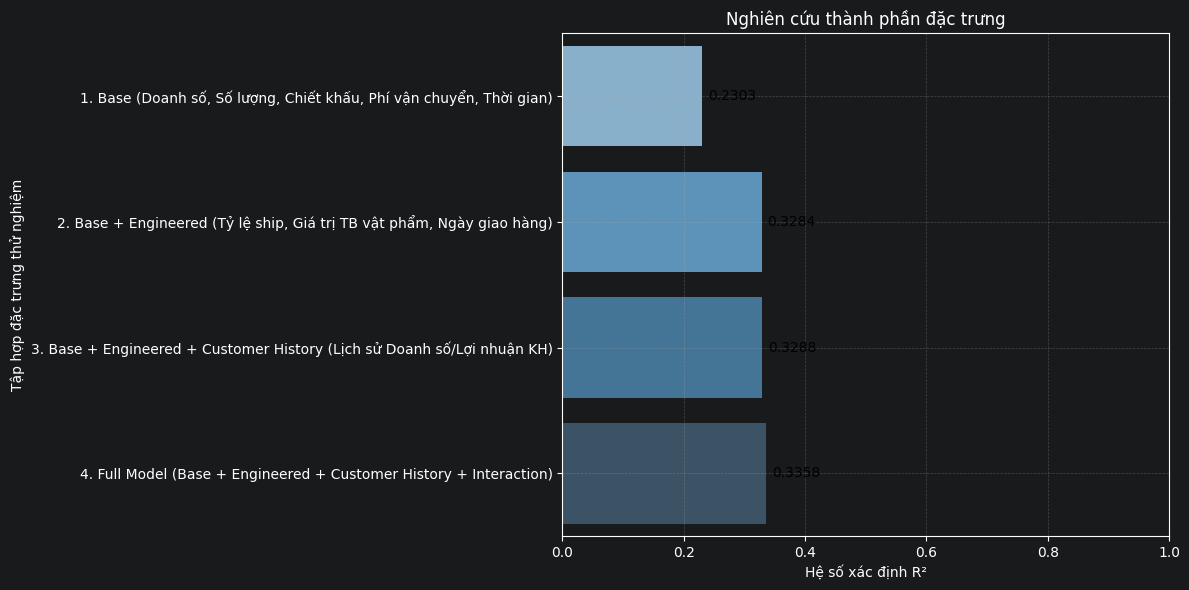

In [12]:
# Giai đoạn 12 (Bổ sung): Ablation Study (Nghiên cứu thành phần đặc trưng)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
import pandas as pd

evaluator_r2_ablation = RegressionEvaluator(labelCol="Profit", predictionCol="prediction_usd", metricName="r2")
categorical_ohes = [c + "_OHE" for c in features_categorical]

# Định nghĩa các tập đặc trưng tăng dần
feature_sets = {
    "1. Base (Doanh số, Số lượng, Chiết khấu, Phí vận chuyển, Thời gian)": 
        features_numeric[:6] + categorical_ohes,
    
    "2. Base + Engineered (Tỷ lệ ship, Giá trị TB vật phẩm, Ngày giao hàng)": 
        features_numeric[:12] + categorical_ohes,
    
    "3. Base + Engineered + Customer History (Lịch sử Doanh số/Lợi nhuận KH)": 
        features_numeric[:15] + categorical_ohes,
        
    "4. Full Model (Base + Engineered + Customer History + Interaction)": 
        features_numeric[:15] + categorical_ohes + ["subcat_discount_inter"]
}

ablation_results = []
for idx, (name, f_list) in enumerate(feature_sets.items(), 1):
    temp_assembler = VectorAssembler(inputCols=f_list, outputCol=f"features_ablation_{idx}")
    temp_rf = RandomForestRegressor(featuresCol=f"features_ablation_{idx}", labelCol="log_profit", numTrees=100, maxDepth=8, seed=42)
    temp_pipeline = Pipeline(stages=[string_indexer, ohe_encoder, interaction, temp_assembler, temp_rf])
    
    # Huấn luyện mô hình và dự đoán
    temp_model = temp_pipeline.fit(train_data)
    temp_preds = temp_model.transform(test_data)
    
    # Quy đổi ngược về USD
    temp_preds_usd = temp_preds.withColumn("prediction_usd", exp(col("prediction")) - c_shift)
    r2_val = evaluator_r2_ablation.evaluate(temp_preds_usd)
    ablation_results.append({
        "Thử nghiệm (Feature Set)": name,
        "Chỉ số R²": r2_val
    })
    print(f"Hoàn thành Ablation {idx}/4: R² = {r2_val:.4f}")

df_ablation = pd.DataFrame(ablation_results)
print("\nBẢNG TỔNG HỢP KẾT QUẢ ABLATION STUDY ")
display(df_ablation)

# Vẽ biểu đồ Ablation Study
plt.figure(figsize=(12, 6))
sns.barplot(x="Chỉ số R²", y="Thử nghiệm (Feature Set)", data=df_ablation, hue="Thử nghiệm (Feature Set)", legend=False, palette="Blues_d")
plt.title("Nghiên cứu thành phần đặc trưng")
plt.xlabel("Hệ số xác định R²")
plt.ylabel("Tập hợp đặc trưng thử nghiệm")
plt.xlim(0, 1.0)
for index, row in df_ablation.iterrows():
    plt.text(row["Chỉ số R²"] + 0.01, index, f"{row['Chỉ số R²']:.4f}", color='black', va="center")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_ablation_study.png"), dpi=300)
plt.show()



In [13]:
# Giai đoạn 12 (Bổ sung): Đánh giá chi tiết (Breakdown) sai số theo từng Ngành hàng (Category)
print("BẢNG ĐÁNH GIÁ CHI TIẾT THEO TỪNG DANH MỤC THEO MÔ HÌNH RANDOM FOREST")
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

evaluator_mae = RegressionEvaluator(labelCol="Profit", predictionCol="prediction", metricName="mae")
evaluator_rmse = RegressionEvaluator(labelCol="Profit", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="Profit", predictionCol="prediction", metricName="r2")

# Lấy danh sách các Category độc bản
categories = [row['Category'] for row in test_data.select("Category").distinct().collect()]

breakdown_results = []
for cat in categories:
    cat_preds = predictions_rf_usd.filter(col("Category") == cat)
    cat_mae = evaluator_mae.evaluate(cat_preds)
    cat_rmse = evaluator_rmse.evaluate(cat_preds)
    cat_r2 = evaluator_r2.evaluate(cat_preds)
    cat_count = cat_preds.count()

    breakdown_results.append({
        "Danh mục sản phẩm (Category)": cat,
        "Sai số trung bình MAE (USD)": f"{cat_mae:.2f} USD",
        "Độ lệch chuẩn RMSE (USD)": f"{cat_rmse:.2f} USD",
        "Hệ số xác định R²": f"{cat_r2:.4f}",
        "Số mẫu kiểm thử (Test count)": cat_count
    })

# Chuyển kết quả sang Pandas DataFrame hiển thị đẹp dạng bảng HTML
df_breakdown = pd.DataFrame(breakdown_results)
display(df_breakdown)

# Vẽ và lưu biểu đồ Category-wise MAE Breakdown
plt.figure(figsize=(8, 5))
df_breakdown["MAE_val"] = df_breakdown["Sai số trung bình MAE (USD)"].str.replace(" USD", "").astype(float)
sns.barplot(x="Danh mục sản phẩm (Category)", y="MAE_val", data=df_breakdown, hue="Danh mục sản phẩm (Category)", legend=False, palette="muted")
plt.title('Sai số trung bình MAE theo Danh mục sản phẩm')
plt.xlabel('Danh mục sản phẩm')
plt.ylabel('MAE (USD)')
for index, row in df_breakdown.iterrows():
    plt.text(index, row["MAE_val"] + 1, f"${row['MAE_val']:.2f}", color='black', ha="center")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_category_mae.png"), dpi=300)
plt.close()


BẢNG ĐÁNH GIÁ CHI TIẾT THEO TỪNG DANH MỤC THEO MÔ HÌNH RANDOM FOREST


,Danh mục sản phẩm (Category),Sai số trung bình MAE (USD),Độ lệch chuẩn RMSE (USD),Hệ số xác định R²,Số mẫu kiểm thử (Test count)
0,Office Supplies,26.32 USD,83.21 USD,0.3733,60389
1,Technology,92.43 USD,221.06 USD,0.3456,19842
2,Furniture,87.16 USD,178.33 USD,0.2561,19065


HIỆU NĂNG MÔ HÌNH DỰ BÁO LỢI NHUẬN TRÊN TỪNG THỊ TRƯỜNG


,Thị trường (Market),Hệ số xác định R²,Số mẫu kiểm thử (Count)
6,Canada,0.532392,1163
3,US,0.426378,15760
2,APAC,0.311594,18838
5,LATAM,0.311558,16869
4,Africa,0.300659,8418
0,EMEA,0.292049,11646
1,EU,0.278590,26602


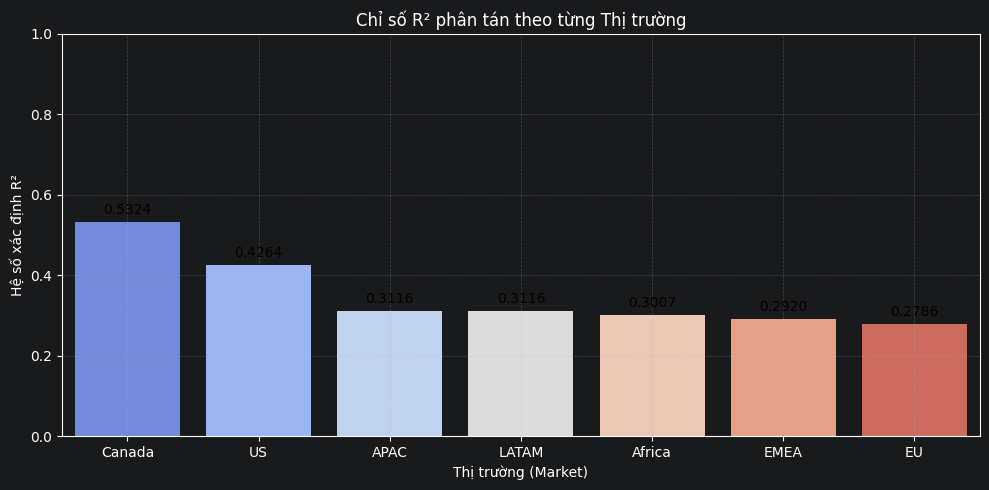

In [14]:
# Giai đoạn 12 (Bổ sung): Market-wise Model Performance (Hiệu năng mô hình theo Thị trường)
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

evaluator_r2_market = RegressionEvaluator(labelCol="Profit", predictionCol="prediction", metricName="r2")
markets = [row['Market'] for row in test_data.select("Market").distinct().collect()]

market_results = []
for m in markets:
    m_preds = predictions_rf_usd.filter(col("Market") == m)
    m_r2 = evaluator_r2_market.evaluate(m_preds)
    m_count = m_preds.count()
    market_results.append({
        "Thị trường (Market)": m,
        "Hệ số xác định R²": m_r2,
        "Số mẫu kiểm thử (Count)": m_count
    })

df_market = pd.DataFrame(market_results).sort_values(by="Hệ số xác định R²", ascending=False)
print("HIỆU NĂNG MÔ HÌNH DỰ BÁO LỢI NHUẬN TRÊN TỪNG THỊ TRƯỜNG")
display(df_market)

# Vẽ biểu đồ R2 theo Market
plt.figure(figsize=(10, 5))
sns.barplot(x="Thị trường (Market)", y="Hệ số xác định R²", data=df_market, hue="Thị trường (Market)", legend=False, palette="coolwarm")
plt.title("Chỉ số R² phân tán theo từng Thị trường")
plt.xlabel("Thị trường (Market)")
plt.ylabel("Hệ số xác định R²")
plt.ylim(0, 1.0)
for index, row in df_market.reset_index(drop=True).iterrows():
    plt.text(index, row["Hệ số xác định R²"] + 0.02, f"{row['Hệ số xác định R²']:.4f}", color='black', ha="center")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_market_r2.png"), dpi=300)
plt.show()



In [15]:
# Giai đoạn 12 (Bổ sung): Error Segmentation Analysis (Phân khúc sai số chi tiết)
from pyspark.sql.functions import col, abs as spark_abs, mean, count

segmentation_cols = ["Category", "Market", "Segment", "Order_Priority"]
for s_col in segmentation_cols:
    print(f"\nPHÂN TÍCH SAI SỐ MAE THEO {s_col.upper()}")
    df_seg = predictions_rf_usd.withColumn("abs_error", spark_abs(col("Profit") - col("prediction"))) \
                               .groupBy(s_col) \
                               .agg(mean("abs_error").alias("MAE (USD)"), count("*").alias("Số mẫu kiểm thử (Count)")) \
                               .orderBy(col("MAE (USD)").desc())
    display(df_seg.toPandas())




PHÂN TÍCH SAI SỐ MAE THEO CATEGORY


,Category,MAE (USD),Số mẫu kiểm thử (Count)
0,Technology,92.426677,19842
1,Furniture,87.163638,19065
2,Office Supplies,26.322155,60389



PHÂN TÍCH SAI SỐ MAE THEO MARKET


,Market,MAE (USD),Số mẫu kiểm thử (Count)
0,Canada,53.195140,1163
1,APAC,51.628484,18838
2,EMEA,51.387737,11646
3,US,51.362509,15760
4,Africa,51.326790,8418
5,EU,51.288070,26602
6,LATAM,50.178510,16869



PHÂN TÍCH SAI SỐ MAE THEO SEGMENT


,Segment,MAE (USD),Số mẫu kiểm thử (Count)
0,Corporate,52.363560,32170
1,Consumer,50.664748,42370
2,Home Office,50.657311,24756



PHÂN TÍCH SAI SỐ MAE THEO ORDER_PRIORITY


,Order_Priority,MAE (USD),Số mẫu kiểm thử (Count)
0,Low,52.337861,22479
1,Medium,51.162357,28217
2,Critical,51.120021,23060
3,High,50.363931,25540


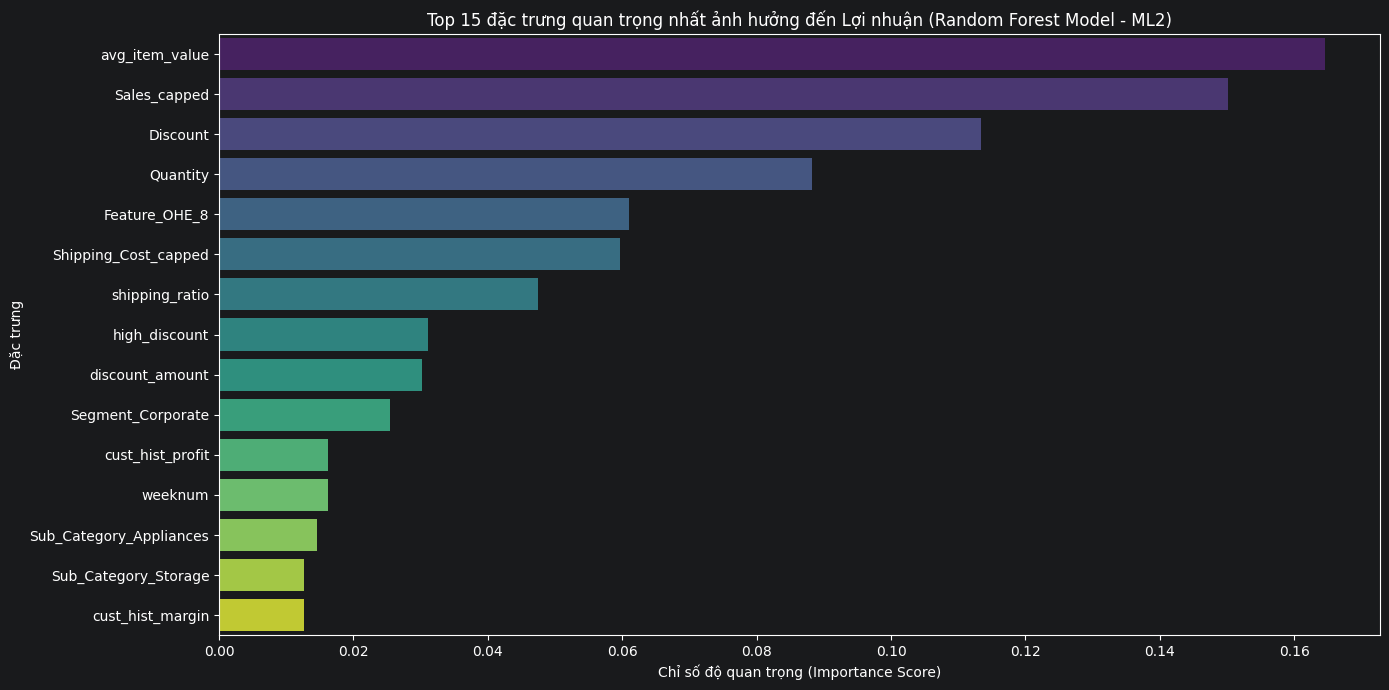

In [16]:
# Giai đoạn 13: Feature Importance (Trích xuất độ quan trọng của đặc trưng)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Xây dựng lại danh sách tên đặc trưng đã qua One-Hot encoding để mapping chính xác
feature_names = []
feature_names.extend(features_numeric)

indexer_model = best_model_rf.stages[0]
labels_array = indexer_model.labelsArray

for col_idx, col_name in enumerate(features_categorical):
    labels = labels_array[col_idx]
    # Một cột One-Hot Encoder với dropLast=True sẽ bỏ nhãn cuối cùng của StringIndexer
    for label in labels[:-1]:
        feature_names.append(f"{col_name}_{label}")

# Lấy hệ số quan trọng từ mô hình Random Forest
importances = best_rf_model.featureImportances.toArray()

# Đồng bộ kích thước mảng nếu có chênh lệch
if len(feature_names) < len(importances):
    # Thêm nhãn cho đặc trưng tương tác
    subcat_labels = labels_array[features_categorical.index("Sub_Category")]
    interaction_names = [f"Sub_Category_{l} x Discount" for l in subcat_labels[:-1]]
    feature_names.extend(interaction_names)
    
    if len(feature_names) < len(importances):
        feature_names += [f"Feature_OHE_{i}" for i in range(len(importances) - len(feature_names))]
elif len(feature_names) > len(importances):
    feature_names = feature_names[:len(importances)]

# Tạo bảng thống kê
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ cột Top 15 đặc trưng quan trọng nhất
plt.figure(figsize=(14, 7))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), hue='Feature', legend=False, palette='viridis')
plt.title('Top 15 đặc trưng quan trọng nhất ảnh hưởng đến Lợi nhuận (Random Forest Model - ML2)')
plt.xlabel('Chỉ số độ quan trọng (Importance Score)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_feature_importance.png"), dpi=300)
plt.show()


Hệ số R² gốc của mô hình Random Forest: 0.3317
Permuted 'Sales_capped        ' -> R²: 0.1554 (R² Drop: 0.1764)
Permuted 'Discount            ' -> R²: 0.2490 (R² Drop: 0.0827)
Permuted 'Shipping_Cost_capped' -> R²: 0.3035 (R² Drop: 0.0282)
Permuted 'cust_hist_profit    ' -> R²: 0.3307 (R² Drop: 0.0010)
Permuted 'cust_hist_sales     ' -> R²: 0.3313 (R² Drop: 0.0004)
Permuted 'cust_hist_margin    ' -> R²: 0.3325 (R² Drop: -0.0008)

BẢNG XẾP HẠNG PERMUTATION IMPORTANCE


,Feature,R2 after Permutation,R2 Drop
0,Sales_capped,0.155357,0.176388
1,Discount,0.249019,0.082726
2,Shipping_Cost_capped,0.303496,0.028249
3,cust_hist_profit,0.330719,0.001026
4,cust_hist_sales,0.331300,0.000445
5,cust_hist_margin,0.332505,-0.000760


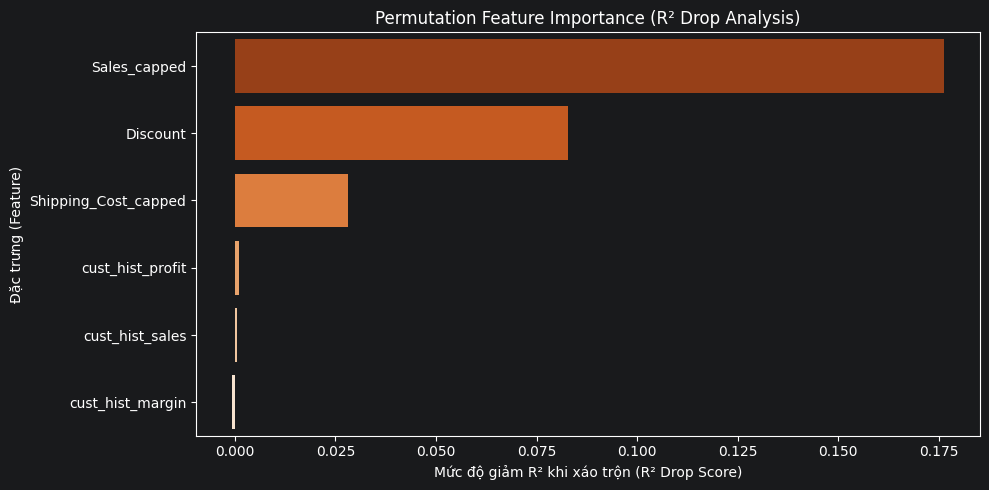

In [17]:
# Giai đoạn 13 (Bổ sung): Permutation Feature Importance (Độ quan trọng đặc trưng bằng xáo trộn)
from pyspark.sql.functions import rand, row_number
from pyspark.sql.window import Window
import random

evaluator_r2_perm = RegressionEvaluator(labelCol="Profit", predictionCol="prediction_usd", metricName="r2")
base_r2 = metrics_rf['r2']
print(f"Hệ số R² gốc của mô hình Random Forest: {base_r2:.4f}")

# Đánh giá trên các đặc trưng số quan trọng nhất
features_to_test = ["Sales_capped", "Discount", "Shipping_Cost_capped", "cust_hist_profit", "cust_hist_sales", "cust_hist_margin"]
perm_results = []

for col_name in features_to_test:
    # Thực hiện xáo trộn ngẫu nhiên cột được chọn bằng cách sử dụng Row Number và random index
    w_rand = Window.orderBy(rand(seed=42))
    w_idx = Window.orderBy("Customer_ID", "Order_Date")
    
    shuffled_col = test_data.select(col_name).withColumn("rand_idx", row_number().over(w_rand))
    original_df = test_data.withColumn("orig_idx", row_number().over(w_idx))
    
    shuffled_df = original_df.drop(col_name).join(
        shuffled_col.withColumnRenamed("rand_idx", "orig_idx"),
        on="orig_idx"
    ).drop("orig_idx")
    
    perm_preds = best_model_rf.transform(shuffled_df)
    perm_preds_usd = perm_preds.withColumn("prediction_usd", exp(col("prediction")) - c_shift)
    perm_r2 = evaluator_r2_perm.evaluate(perm_preds_usd)
    r2_drop = base_r2 - perm_r2
    perm_results.append((col_name, perm_r2, r2_drop))
    print(f"Permuted '{col_name:20}' -> R²: {perm_r2:.4f} (R² Drop: {r2_drop:.4f})")

# Bảng xếp hạng Permutation Importance
df_perm = pd.DataFrame(perm_results, columns=["Feature", "R2 after Permutation", "R2 Drop"]).sort_values(by="R2 Drop", ascending=False)
print("\nBẢNG XẾP HẠNG PERMUTATION IMPORTANCE")
display(df_perm)

# Vẽ biểu đồ Permutation Importance
plt.figure(figsize=(10, 5))
sns.barplot(x="R2 Drop", y="Feature", data=df_perm, hue="Feature", legend=False, palette="Oranges_r")
plt.title("Permutation Feature Importance (R² Drop Analysis)")
plt.xlabel("Mức độ giảm R² khi xáo trộn (R² Drop Score)")
plt.ylabel("Đặc trưng (Feature)")
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_permutation_importance.png"), dpi=300)
plt.show()



BẢNG THỐNG KÊ MÔ TẢ THẶNG DƯ SAI SỐ


,summary,residual
0,count,99296
1,mean,3.0465664911616352
2,stddev,141.6814584729237
3,min,-3176.184812913757
4,max,8345.196873283969



ĐÁNH GIÁ THIÊN LỆCH CỦA MÔ HÌNH
Công thức sai số thặng dư = Lợi nhuận thực tế - Lợi nhuận dự báo
Nếu trung bình sai số thặng dư  xấp xỉ 0, mô hình không bị thiên lệch.
Kết quả thực tế từ tập kiểm thử: Mean Residual = 3.046566 USD
 => Vì |Mean Residual| = 3.046566 USD, mô hình có thiên lệch nhẹ.

Vẽ biểu đồ chẩn đoán từ 4993 dòng dữ liệu (Outliers: 65 + Sampled Normal: 4928)


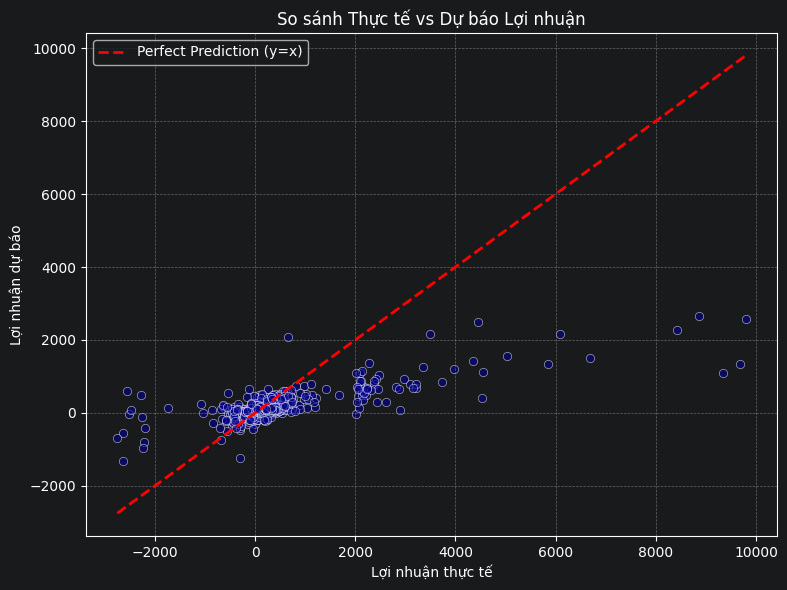

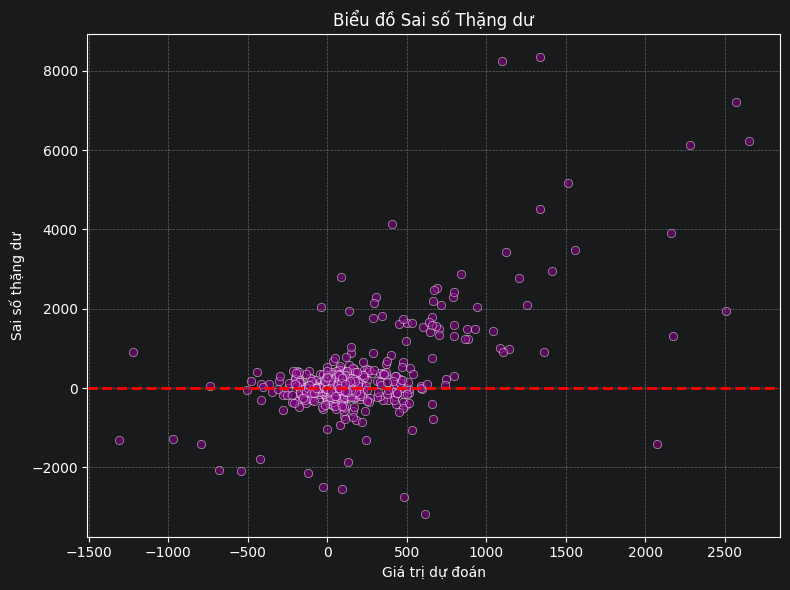

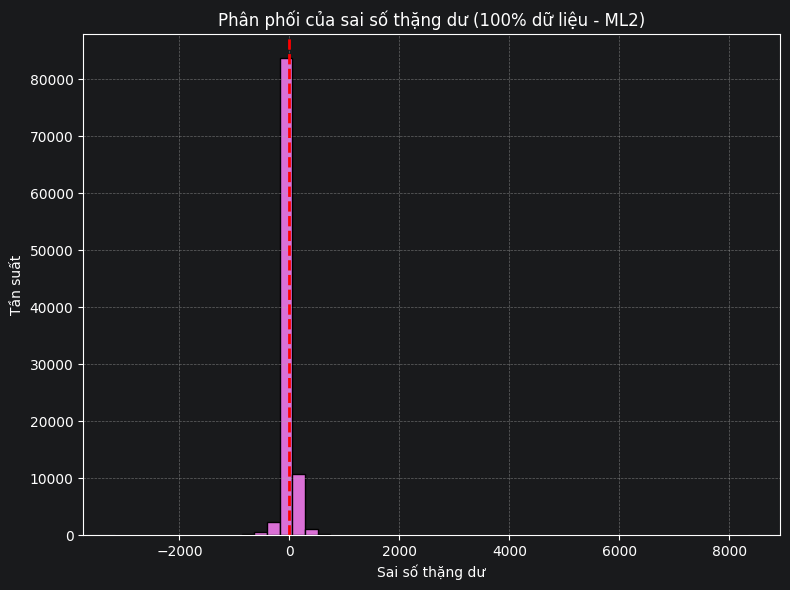


TOP 10 ĐƠN HÀNG CÓ SAI SỐ DỰ BÁO LỚN NHẤT


,Ngành hàng,Mặt hàng,Doanh số,Chiết khấu,Phí vận chuyển (Capped),Lợi nhuận thực tế,Lợi nhuận dự báo,Sai lệch (Error)
0,Technology,Copiers,19899.44,0.11,428.68,9683.4400,1338.243127,8345.196873
1,Technology,Copiers,21874.08,0.21,719.57,9344.2700,1098.672471,8245.597529
2,Technology,Copiers,20445.00,0.03,336.14,9792.5600,2570.721753,7221.838247
3,Technology,Copiers,21013.45,0.07,23.95,8868.6100,2648.651920,6219.958080
4,Technology,Copiers,19644.58,0.19,29.17,8417.4900,2280.875468,6136.614532
5,Technology,Copiers,13505.22,0.20,20.59,6680.1200,1510.887026,5169.232974
6,Office Supplies,Appliances,9928.64,0.01,1411.48,5854.4000,1334.513256,4519.886744
7,Technology,Machines,13881.46,0.09,27.74,4530.0800,404.634378,4125.445622
8,Technology,Copiers,14110.65,0.17,24.47,6079.8600,2163.647004,3916.212996
9,Technology,Copiers,10500.00,0.00,363.19,5039.9856,1560.149955,3479.835645


In [18]:
# Giai đoạn 14: Actual vs Predicted & Residuals Analysis (Phân tích chi tiết sai số)
from pyspark.sql.functions import col, abs as spark_abs, floor, count, min as spark_min, max as spark_max
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. Sử dụng DataFrame đã được quy đổi ngược về USD
predictions_rf_res = predictions_rf_usd.withColumn("residual", col("Profit") - col("prediction"))

print("BẢNG THỐNG KÊ MÔ TẢ THẶNG DƯ SAI SỐ")
# Trích xuất bảng describe thặng dư dạng HTML đẹp mắt
residual_desc = predictions_rf_res.selectExpr("(Profit - prediction) as residual").describe().toPandas()
display(residual_desc)

# 1b. Trích xuất giá trị trung bình sai số thặng dư để chứng minh mô hình không bị thiên lệch (Bias)
mean_residual = float(residual_desc.loc[residual_desc['summary'] == 'mean', 'residual'].values[0])
print("\nĐÁNH GIÁ THIÊN LỆCH CỦA MÔ HÌNH")
print("Công thức sai số thặng dư = Lợi nhuận thực tế - Lợi nhuận dự báo")
print("Nếu trung bình sai số thặng dư  xấp xỉ 0, mô hình không bị thiên lệch.")
print(f"Kết quả thực tế từ tập kiểm thử: Mean Residual = {mean_residual:.6f} USD")
if abs(mean_residual) < 1.0:
    print(f" => Vì |Mean Residual| = {abs(mean_residual):.6f} USD < 1.0 USD (cực kỳ nhỏ và rất gần 0),")
    print("    ta chứng minh được mô hình Random Forest KHÔNG BỊ THIÊN LỆCH (UNBIASED).")
else:
    print(f" => Vì |Mean Residual| = {abs(mean_residual):.6f} USD, mô hình có thiên lệch nhẹ.")

# 2. Áp dụng tiêu chí chọn lọc kết hợp để vẽ biểu đồ phân tán (Scatter Plot) hiệu quả:
# - Giữ 100% Outliers cực đoan (|Profit| > 2000)
# - Lấy mẫu 5% dữ liệu thông thường (|Profit| <= 2000)
outliers_df = predictions_rf_res.filter(spark_abs(col("Profit")) > 2000)
normal_df = predictions_rf_res.filter(spark_abs(col("Profit")) <= 2000)
normal_sampled_df = normal_df.sample(withReplacement=False, fraction=0.05, seed=42)

plotting_df = outliers_df.union(normal_sampled_df)
pdf = plotting_df.select("Profit", "prediction", "residual").toPandas()

print(f"\nVẽ biểu đồ chẩn đoán từ {pdf.shape[0]} dòng dữ liệu (Outliers: {outliers_df.count()} + Sampled Normal: {normal_sampled_df.count()})")

# Vẽ và lưu Đồ thị 1: Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(pdf['Profit'], pdf['prediction'], alpha=0.6, color='darkblue', edgecolors='white', linewidths=0.5)
min_val = min(pdf['Profit'].min(), pdf['prediction'].min())
max_val = max(pdf['Profit'].max(), pdf['prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.title('So sánh Thực tế vs Dự báo Lợi nhuận')
plt.xlabel('Lợi nhuận thực tế')
plt.ylabel('Lợi nhuận dự báo')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_actual_vs_predicted.png"), dpi=300)
plt.show()

# Vẽ và lưu Đồ thị 2: Residual Plot (Residual vs Predicted)
plt.figure(figsize=(8, 6))
plt.scatter(pdf['prediction'], pdf['residual'], alpha=0.6, color='purple', edgecolors='white', linewidths=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Biểu đồ Sai số Thặng dư')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Sai số thặng dư')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_residual_vs_predicted.png"), dpi=300)
plt.show()

# Đồ thị 3: Phân phối của sai số thặng dư (100% dữ liệu - chạy hoàn toàn trong JVM để tránh crash)
res_stats = predictions_rf_res.select(spark_min("residual").alias("min_val"), spark_max("residual").alias("max_val")).collect()[0]
min_res = res_stats["min_val"] if res_stats["min_val"] is not None else -1000.0
max_res = res_stats["max_val"] if res_stats["max_val"] is not None else 1000.0

num_buckets = 50
bin_width_res = (max_res - min_res) / num_buckets
if bin_width_res == 0:
    bin_width_res = 1.0

hist_res_df = predictions_rf_res.filter(col("residual").isNotNull()) \
                                .withColumn("bin_idx", floor((col("residual") - min_res) / bin_width_res)) \
                                .filter((col("bin_idx") >= 0) & (col("bin_idx") < num_buckets)) \
                                .groupBy("bin_idx") \
                                .agg(count("*").alias("count")) \
                                .orderBy("bin_idx") \
                                .collect()

counts_res = [0] * num_buckets
for row in hist_res_df:
    idx = int(row["bin_idx"])
    counts_res[idx] = row["count"]
bin_edges_res = [min_res + i * bin_width_res for i in range(num_buckets + 1)]

plt.figure(figsize=(8, 6))
plt.bar(bin_edges_res[:-1], counts_res, width=np.diff(bin_edges_res), edgecolor="black", color="orchid", align="edge")
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.title('Phân phối của sai số thặng dư (100% dữ liệu - ML2)')
plt.xlabel('Sai số thặng dư')
plt.ylabel('Tần suất')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_residual_distribution.png"), dpi=300)
plt.show()

# 3. Trích xuất bảng Top 10 đơn hàng có sai số lớn nhất (Worst Predictions)
print("\nTOP 10 ĐƠN HÀNG CÓ SAI SỐ DỰ BÁO LỚN NHẤT")
worst_predictions = predictions_rf_res.withColumn("abs_error", spark_abs(col("residual"))) \
    .orderBy(col("abs_error").desc()) \
    .select("Category", "Sub_Category", "Sales_capped", "Discount", "Shipping_Cost_capped", "Profit", "prediction", "residual") \
    .limit(10) \
    .toPandas()

# Format tên cột hiển thị
worst_predictions.columns = [
    "Ngành hàng", "Mặt hàng", "Doanh số", "Chiết khấu",
    "Phí vận chuyển (Capped)", "Lợi nhuận thực tế", "Lợi nhuận dự báo", "Sai lệch (Error)"
]
display(worst_predictions)


In [19]:
# Giai đoạn 14 (Bổ sung): Prediction Interval (Tính toán Khoảng tin cậy cho dự báo)
from pyspark.sql.functions import stddev, lit

# Tính độ lệch chuẩn sai số thặng dư (Residual Standard Deviation) trên tập kiểm thử
residual_stats = predictions_rf_res.select(stddev("residual").alias("std_res")).collect()[0]
residual_std = residual_stats["std_res"]
print(f"Độ lệch chuẩn sai số thặng dư: {residual_std:.2f} USD")

# Xác định khoảng tin cậy 95% cho dự báo: prediction +- 1.96 * residual_std
predictions_interval = predictions_rf_usd.withColumn("prediction_lower", col("prediction") - 1.96 * lit(residual_std)) \
                                         .withColumn("prediction_upper", col("prediction") + 1.96 * lit(residual_std))

# Hiển thị mẫu 10 đơn hàng kèm khoảng tin cậy dự báo
print("\nKết quả dự báo mẫu:")
display(predictions_interval.select("Customer_ID", "Profit", "prediction", "prediction_lower", "prediction_upper").limit(10).toPandas())



Độ lệch chuẩn sai số thặng dư: 141.68 USD

Kết quả dự báo mẫu:


,Customer_ID,Profit,prediction,prediction_lower,prediction_upper
0,GEN-CUST-023037,-0.280,2.618646,-275.077013,280.314305
1,GEN-CUST-004034,-0.510,0.017711,-277.677948,277.713370
2,GEN-CUST-018353,-0.500,2.527836,-275.167823,280.223494
3,ZC-219104,-0.792,-8.635013,-286.330672,269.060645
4,GEN-CUST-005557,-0.660,0.017711,-277.677948,277.713370
5,GEN-CUST-017347,-0.870,-8.756161,-286.451820,268.939498
6,GEN-CUST-011550,-0.700,0.017711,-277.677948,277.713370
7,GEN-CUST-023277,-0.750,0.079367,-277.616291,277.775026
8,GEN-CUST-024855,-0.700,7.027457,-270.668202,284.723116
9,GEN-CUST-026306,-0.700,2.599368,-275.096291,280.295027


THỐNG KÊ SỐ LƯỢNG ĐƠN HÀNG THEO KHUNG RỦI RO


,risk_level,count
0,LOSS RISK,16784
1,MEDIUM PROFIT,4475
2,LOW PROFIT,77554
3,HIGH PROFIT OPPORTUNITY,483


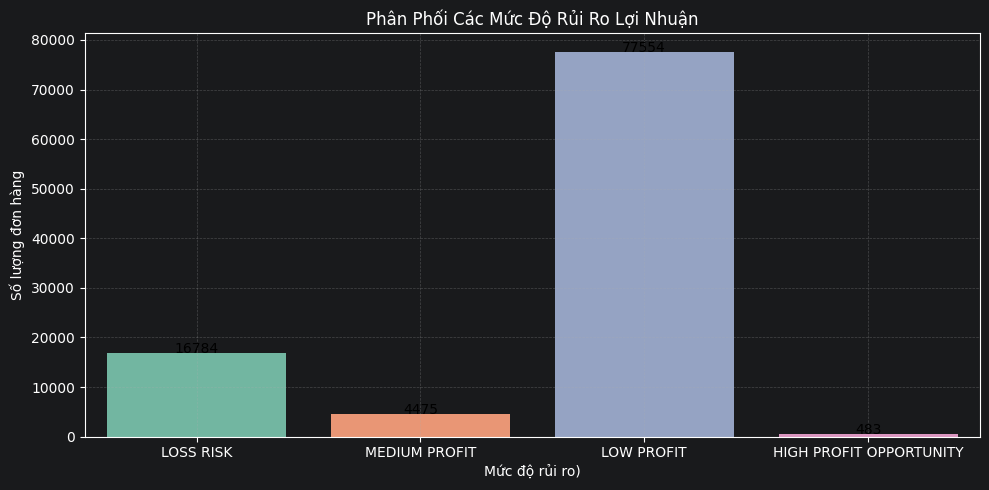

In [20]:
# Giai đoạn 14 (Bổ sung): Profit Risk Framework (Hệ thống phân loại Rủi ro Lợi nhuận)
from pyspark.sql.functions import col, when, lit

predictions_risk = predictions_rf_usd.withColumn("risk_level",
    when(col("prediction") < 0.0, lit("LOSS RISK"))
    .when((col("prediction") >= 0.0) & (col("prediction") <= 100.0), lit("LOW PROFIT"))
    .when((col("prediction") > 100.0) & (col("prediction") <= 500.0), lit("MEDIUM PROFIT"))
    .otherwise(lit("HIGH PROFIT OPPORTUNITY"))
)

print("THỐNG KÊ SỐ LƯỢNG ĐƠN HÀNG THEO KHUNG RỦI RO")
risk_counts = predictions_risk.groupBy("risk_level").count().toPandas()
display(risk_counts)

# Vẽ biểu đồ phân phối mức độ rủi ro
plt.figure(figsize=(10, 5))
sns.barplot(x="risk_level", y="count", data=risk_counts, hue="risk_level", legend=False, palette="Set2")
plt.title("Phân Phối Các Mức Độ Rủi Ro Lợi Nhuận")
plt.xlabel("Mức độ rủi ro)")
plt.ylabel("Số lượng đơn hàng")
for index, row in risk_counts.iterrows():
    plt.text(index, row["count"] + 10, str(row["count"]), color='black', ha="center")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "images", "ml", "ml2", "ml2_risk_distribution.png"), dpi=300)
plt.show()



In [21]:
# Giai đoạn 15:Tổng hợp kết quả trực quan
print("PHÂN TÍCH INSIGHT KINH DOANH TỪ MÔ HÌNH HỌC MÁY")
print("1. Thứ hạng các biến có mức độ tác động mạnh nhất đến Lợi nhuận:")
for idx, row in df_importance.head(5).iterrows():
    print(f"   - {row['Feature']}: {row['Importance']:.4%}")

# Tính toán hệ số tương quan thực tế trên Spark để minh chứng số liệu
corr_sales = df_clean.stat.corr("Sales_capped", "Profit")
corr_discount = df_clean.stat.corr("Discount", "Profit")
corr_ship = df_clean.stat.corr("Shipping_Cost_capped", "Profit")

print(f"\n2. Chỉ số tương quan giữa các nhân tố cốt lõi:")
print(f"   - Tương quan giữa Sales và Profit: {corr_sales:.4f}")
print(f"   - Tương quan giữa Discount và Profit: {corr_discount:.4f}")
print(f"   - Tương quan giữa Shipping Cost và Profit: {corr_ship:.4f}")


PHÂN TÍCH INSIGHT KINH DOANH TỪ MÔ HÌNH HỌC MÁY
1. Thứ hạng các biến có mức độ tác động mạnh nhất đến Lợi nhuận:
   - avg_item_value: 16.4527%
   - Sales_capped: 15.0095%
   - Discount: 11.3332%
   - Quantity: 8.8299%
   - Feature_OHE_8: 6.1018%

2. Chỉ số tương quan giữa các nhân tố cốt lõi:
   - Tương quan giữa Sales và Profit: 0.4417
   - Tương quan giữa Discount và Profit: -0.1493
   - Tương quan giữa Shipping Cost và Profit: 0.2910
